In [6]:
from pathlib import Path
import pandas as pd


# ============================================================
# 1. Load combined prediction_daily
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")
combined_path = pred_dir / "prediction_daily_EPlus_RC_combined.csv"

prediction_daily = pd.read_csv(combined_path)
prediction_daily["timestamp"] = pd.to_datetime(prediction_daily["timestamp"])


# ============================================================
# 2. Repair scenario_group and scenario_label
# ============================================================

def infer_eplus_group(row):
    text = " ".join([
        str(row.get("scenario_group", "")),
        str(row.get("scenario_label", "")),
        str(row.get("sample_id", "")),
        str(row.get("experiment_id", "")),
    ])

    if "4P__beta" in text or "_beta" in text:
        return "_beta"
    if "4P__gamma" in text or "_gamma" in text:
        return "_gamma"
    if "4P_bY" in text or "bY" in text:
        return "bY"

    return "unknown"


def infer_rc_group(row):
    text = " ".join([
        str(row.get("scenario_group", "")),
        str(row.get("scenario_label", "")),
        str(row.get("sample_id", "")),
        str(row.get("experiment_id", "")),
    ])

    if "default_occ" in text:
        return "default_occ"
    if "ONSITE_occ" in text:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in text:
        return "bldg_LoD_Y"

    return "unknown"


def repair_group(row):
    source = str(row.get("source", ""))
    model = str(row.get("model_name", ""))

    if source == "EPlus" or model == "EnergyPlus":
        return infer_eplus_group(row)

    if source == "RC" or model in {"5R1C", "3R2C"}:
        return infer_rc_group(row)

    return str(row.get("scenario_group", "unknown"))


prediction_daily["scenario_group"] = prediction_daily.apply(
    repair_group,
    axis=1,
)

label_map = {
    "_beta": r"LoD-1: $ihg^{1}_{1}$",
    "_gamma": r"LoD-2: $ihg^{2}_{1}$",
    "bY": r"LoD-3: $ihg^{3}_{1}$",
    "default_occ": "LoD-1: default occupancy",
    "ONSITE_occ": "LoD-2: on-site occupancy",
    "bldg_LoD_Y": "LoD-3: building LoD-Y occupancy",
}

prediction_daily["scenario_label"] = prediction_daily["scenario_group"].map(
    label_map
)

display(
    prediction_daily.groupby(
        ["source", "model_name", "scenario_group"]
    )["sample_id"].nunique()
)

source  model_name  scenario_group
EPlus   EnergyPlus  _beta             10
                    _gamma            10
                    bY                10
                    unknown           20
RC      3R2C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
        5R1C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
Name: sample_id, dtype: int64

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def add_engine_quality_keys(prediction_daily):
    df = prediction_daily.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    def engine_key(row):
        model = str(row.get("model_name", ""))
        source = str(row.get("source", ""))

        if source == "EPlus" or model == "EnergyPlus":
            return "EnergyPlus"
        if model == "5R1C":
            return "5R1C"
        if model == "3R2C":
            return "3R2C"

        return model

    df["engine_key"] = df.apply(engine_key, axis=1)

    quality_map = {
        "_beta": "LoD-1",
        "_gamma": "LoD-2",
        "bY": "LoD-3",
        "default_occ": "LoD-1",
        "ONSITE_occ": "LoD-2",
        "bldg_LoD_Y": "LoD-3",
    }

    df["data_quality"] = df["scenario_group"].map(quality_map)

    # Keep only LoD-1 to LoD-3
    df = df[df["data_quality"].notna()].copy()

    return df

In [8]:
def plot_prediction_daily_engine_quality_3x3(
    prediction_daily,
    _start="2023-01-20",
    _end="2023-03-17",
    engine_order=("EnergyPlus", "5R1C", "3R2C"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
    quality_label_map=None,
    ylabel=r"Daily heating energy use ($\mathrm{kWh\,m^{-2}}$)",
    figsize=(13, 10),
    alpha_band=0.25,
    save_path=None,
):
    df = add_engine_quality_keys(prediction_daily)

    df = df.loc[
        (df["timestamp"] >= pd.to_datetime(_start))
        & (df["timestamp"] <= pd.to_datetime(_end))
    ].copy()

    if df.empty:
        raise ValueError("No data found in the selected period.")

    if quality_label_map is None:
        quality_label_map = {
            "LoD-1": r"LoD-1: $ihg^{1}_{1}$",
            "LoD-2": r"LoD-2: $ihg^{2}_{1}$",
            "LoD-3": r"LoD-3: $ihg^{3}_{1}$",
        }

    # Make sure daily values are unique per sample/date.
    sim_daily = (
        df
        .groupby(
            ["engine_key", "data_quality", "sample_id", "timestamp"],
            as_index=False,
        )
        .agg(sim_heating=("sim_heating", "sum"))
    )

    metered_daily = (
        df
        .dropna(subset=["metered_heating"])
        .groupby("timestamp", as_index=True)["metered_heating"]
        .first()
        .sort_index()
    )

    fig, axes = plt.subplots(
        len(engine_order),
        len(quality_order),
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    if len(engine_order) == 1:
        axes = axes.reshape(1, -1)
    if len(quality_order) == 1:
        axes = axes.reshape(-1, 1)

    for i, engine in enumerate(engine_order):
        for j, quality in enumerate(quality_order):
            ax = axes[i, j]

            sub = sim_daily[
                (sim_daily["engine_key"] == engine)
                & (sim_daily["data_quality"] == quality)
            ].copy()

            if sub.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_axis_off()
                continue

            wide = sub.pivot_table(
                index="timestamp",
                columns="sample_id",
                values="sim_heating",
                aggfunc="sum",
            ).sort_index()

            q05 = wide.quantile(0.05, axis=1)
            q50 = wide.quantile(0.50, axis=1)
            q95 = wide.quantile(0.95, axis=1)

            metered = metered_daily.reindex(wide.index)

            ax.fill_between(
                wide.index,
                q05.values,
                q95.values,
                alpha=alpha_band,
                zorder=1,
            )

            ax.plot(
                wide.index,
                q50.values,
                linestyle="--",
                linewidth=1.4,
                zorder=2,
            )

            ax.plot(
                wide.index,
                metered.values,
                color="black",
                linewidth=1.5,
                zorder=3,
            )

            if i == 0:
                ax.set_title(quality_label_map.get(quality, quality), fontsize=11)

            if j == 0:
                ax.set_ylabel(f"{engine}\n{ylabel}")

            ax.set_ylim(bottom=0)
            ax.grid(True, alpha=0.3)
            ax.margins(x=0)

            ticks = pd.date_range(wide.index.min(), wide.index.max(), freq="12D")
            ticks = pd.DatetimeIndex(ticks).union(
                pd.DatetimeIndex([wide.index.max()])
            )
            ticks = ticks.sort_values()

            if len(ticks) >= 2 and (ticks[-1] - ticks[-2]).days < 7:
                ticks = ticks.delete(-2)

            ax.set_xticks(ticks)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
            ax.tick_params(axis="x", rotation=0)

    handles = [
        Line2D(
            [0],
            [0],
            color="black",
            lw=1.5,
            label="Metered data",
        ),
        Line2D(
            [0],
            [0],
            color="grey",
            lw=1.4,
            linestyle="--",
            label=r"Simulated data ($q_{0.50}$)",
        ),
        Patch(
            facecolor="grey",
            alpha=alpha_band,
            label=r"Simulated data ($q_{0.05}$--$q_{0.95}$)",
        ),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    plt.tight_layout(rect=(0, 0, 1, 0.96))

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

In [9]:
def plot_prediction_daily_engine_quality_3x3(
    prediction_daily,
    _start="2023-01-20",
    _end="2023-03-17",
    engine_order=("EnergyPlus", "5R1C", "3R2C"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
    quality_label_map=None,
    ylabel=r"Daily heating energy use ($\mathrm{kWh\,m^{-2}}$)",
    figsize=(13, 10),
    alpha_band=0.25,
    save_path=None,
):
    df = add_engine_quality_keys(prediction_daily)

    df = df.loc[
        (df["timestamp"] >= pd.to_datetime(_start))
        & (df["timestamp"] <= pd.to_datetime(_end))
    ].copy()

    if df.empty:
        raise ValueError("No data found in the selected period.")

    if quality_label_map is None:
        quality_label_map = {
            "LoD-1": r"LoD-1: $ihg^{1}_{1}$",
            "LoD-2": r"LoD-2: $ihg^{2}_{1}$",
            "LoD-3": r"LoD-3: $ihg^{3}_{1}$",
        }

    # Make sure daily values are unique per sample/date.
    sim_daily = (
        df
        .groupby(
            ["engine_key", "data_quality", "sample_id", "timestamp"],
            as_index=False,
        )
        .agg(sim_heating=("sim_heating", "sum"))
    )

    metered_daily = (
        df
        .dropna(subset=["metered_heating"])
        .groupby("timestamp", as_index=True)["metered_heating"]
        .first()
        .sort_index()
    )

    fig, axes = plt.subplots(
        len(engine_order),
        len(quality_order),
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    if len(engine_order) == 1:
        axes = axes.reshape(1, -1)
    if len(quality_order) == 1:
        axes = axes.reshape(-1, 1)

    for i, engine in enumerate(engine_order):
        for j, quality in enumerate(quality_order):
            ax = axes[i, j]

            sub = sim_daily[
                (sim_daily["engine_key"] == engine)
                & (sim_daily["data_quality"] == quality)
            ].copy()

            if sub.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_axis_off()
                continue

            wide = sub.pivot_table(
                index="timestamp",
                columns="sample_id",
                values="sim_heating",
                aggfunc="sum",
            ).sort_index()

            q05 = wide.quantile(0.05, axis=1)
            q50 = wide.quantile(0.50, axis=1)
            q95 = wide.quantile(0.95, axis=1)

            metered = metered_daily.reindex(wide.index)

            ax.fill_between(
                wide.index,
                q05.values,
                q95.values,
                alpha=alpha_band,
                zorder=1,
            )

            ax.plot(
                wide.index,
                q50.values,
                linestyle="--",
                linewidth=1.4,
                zorder=2,
            )

            ax.plot(
                wide.index,
                metered.values,
                color="black",
                linewidth=1.5,
                zorder=3,
            )

            if i == 0:
                ax.set_title(quality_label_map.get(quality, quality), fontsize=11)

            if j == 0:
                ax.set_ylabel(f"{engine}\n{ylabel}")

            ax.set_ylim(bottom=0)
            ax.grid(True, alpha=0.3)
            ax.margins(x=0)

            ticks = pd.date_range(wide.index.min(), wide.index.max(), freq="12D")
            ticks = pd.DatetimeIndex(ticks).union(
                pd.DatetimeIndex([wide.index.max()])
            )
            ticks = ticks.sort_values()

            if len(ticks) >= 2 and (ticks[-1] - ticks[-2]).days < 7:
                ticks = ticks.delete(-2)

            ax.set_xticks(ticks)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
            ax.tick_params(axis="x", rotation=0)

    handles = [
        Line2D(
            [0],
            [0],
            color="black",
            lw=1.5,
            label="Metered data",
        ),
        Line2D(
            [0],
            [0],
            color="grey",
            lw=1.4,
            linestyle="--",
            label=r"Simulated data ($q_{0.50}$)",
        ),
        Patch(
            facecolor="grey",
            alpha=alpha_band,
            label=r"Simulated data ($q_{0.05}$--$q_{0.95}$)",
        ),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    plt.tight_layout(rect=(0, 0, 1, 0.96))

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

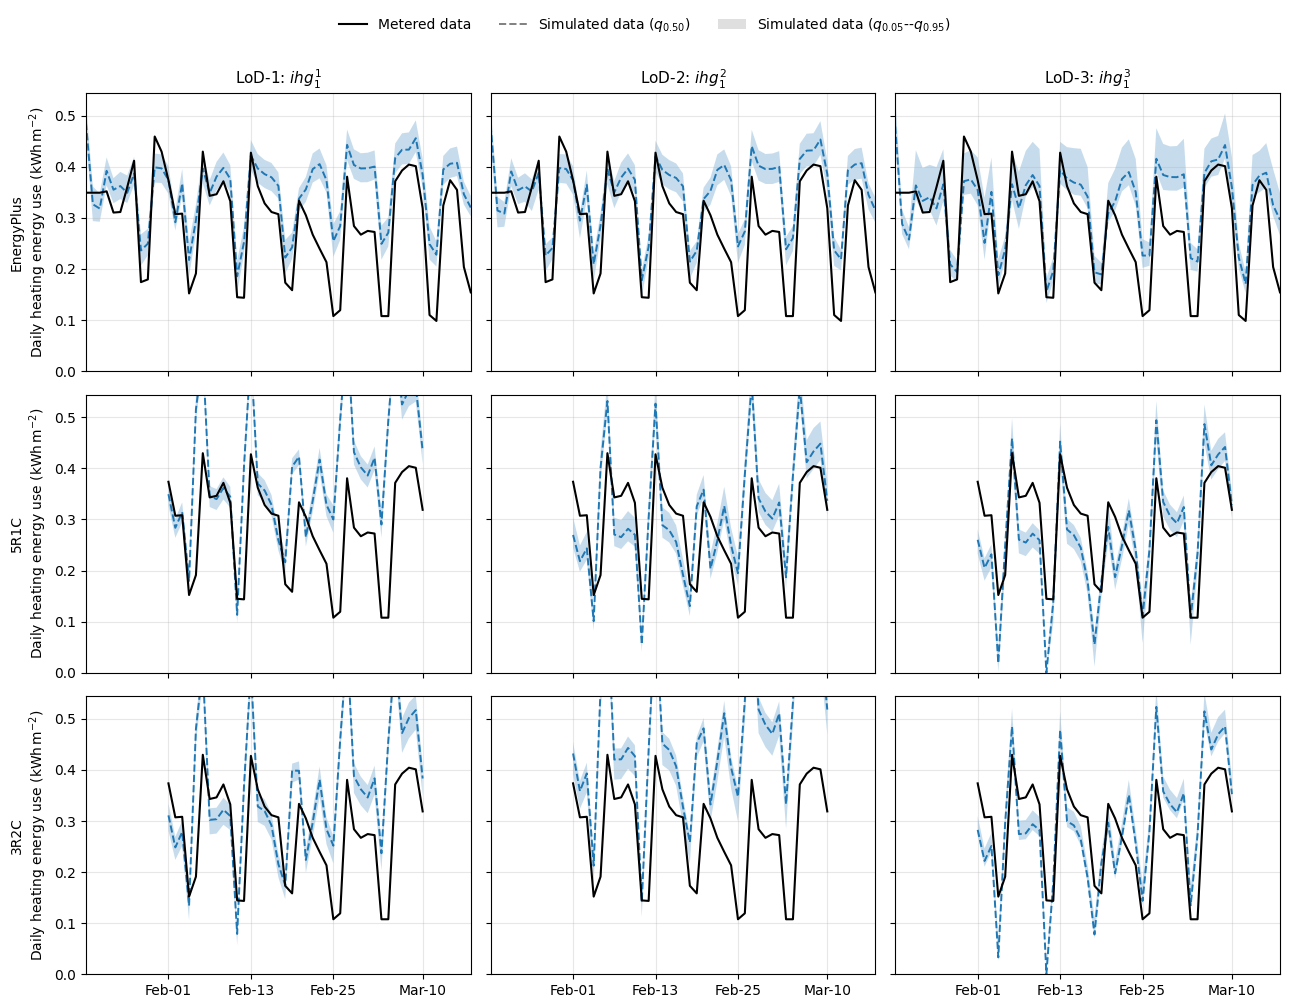

In [10]:
fig, axes = plot_prediction_daily_engine_quality_3x3(
    prediction_daily=prediction_daily,
    _start="2023-01-20",
    _end="2023-03-17",
    save_path=Path("_json/_run/JUN11/_prediction_daily/prediction_daily_3x3.png"),
)